<a href="https://colab.research.google.com/github/ZahraAbedian/Efficient-and-Edge-AI-Menstrual-Health-Symptom-Risk-Prediction-and-Decision-Support-/blob/main/Edge_AI_Menstrual_Health_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Edge AI Menstrual Health: Symptom Risk Prediction Pipeline**

This notebook demonstrates an end-to-end Edge AI workflow for predicting next-day menstrual symptom risk using passive wearable data. It focuses on balancing predictive performance with edge-efficiency (low latency and small model size).

## Table of Contents
1.  **[Setup](#1.-Setup)**: Environment configuration and library imports.
2.  **[Data Loading](#2.-Load-the-required-CSV-tables)**: Importing raw wearable and symptom datasets.
3.  **[Target Engineering](#3.-Create-the-prediction-target)**: Defining the classification label from self-reports.
4.  **[Feature Versions (V1-V4)](#4.-Feature-engineering)**: Incremental signal testing (Sleep, Activity, RHR, HRV, Temperature).
5.  **[Modelling Helper Functions](#5.-Modelling-helper-functions)**: Scikit-learn pipelines with GroupKFold validation.
6.  **[Baselines](#6.-Naive-baseline)**: Comparing ML performance against a naive majority-class baseline.
7.  **[Performance Evaluation](#7.-Evaluate-all-feature-versions)**: Detailed comparison of Logistic Regression, Decision Trees, and Random Forests.
8.  **[Version Comparison](#8.-Compare-best-models-across-versions)**: Visualizing the impact of different sensor groups.
9.  **[Edge Efficiency](#9.-Edge-AI-data-reduction:-bandwidth-and-energy-cost-evidence)**: Evidence for bandwidth savings through local daily aggregation.
10. **[Threshold Tuning](#10.-Threshold-analysis-using-out-of-fold-predictions)**: Optimizing for recall to minimize missed symptom flares.
11. **[Final Model Selection](#11.-Final-selected-model)**: Selection of the V3 Logistic Regression pipeline.
12. **[Final out-of-fold risk-category analysis](#13.-Final-out-of-fold-risk-category-analysis)**: Analyzing how the final model's predictions behave across different risk categories.
13. **[Explainability (XAI)](#14.-Explainability:-coefficient-table-for-the-final-model)**: SHAP interpretability and coefficient analysis.
14. **[Additional Explainability: SHAP XAI](#15.-Additional-Explainability:-SHAP-XAI)**: SHAP XAI for more detailed explanations.
15. **[Decision Support](#16.-Example-decision-support-output)**: Translating probabilities into actionable user 'Planning Cards'.
16. **[Raspberry Pi deployment](#17.-Raspberry-Pi-deployment)**: Exporting the model and supporting files for deployment.

**AI declaration:** I used AI tools to create the structure of the notebook, and refine the markdown explanations. The coding was developed and organised by me while studying Python, pandas, scikit-learn official documentation, and relevant library documentation. Also, Model training, evaluation decisions, result analysis, plots, and interpretation were carried out by me based on my notebook outputs.


# 1. Setup

This section mounts Google Drive, imports the required libraries, and defines the project folders.

In [ ]:
# Mount Google Drive in Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import time
import shutil
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

PROJECT_ROOT = Path("/content/drive/MyDrive/EdgeAI_Project")
DATA_RAW = PROJECT_ROOT / "data" / "raw"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_RAW)
print("Model folder:", MODEL_DIR)
print("Raw folder exists?", DATA_RAW.exists())


Project root: /content/drive/MyDrive/EdgeAI_Project
Raw data folder: /content/drive/MyDrive/EdgeAI_Project/data/raw
Model folder: /content/drive/MyDrive/EdgeAI_Project/models
Raw folder exists? True


---

# 2. Load the required CSV tables

Only the tables needed for the current modelling experiments are loaded:

- `hormones_and_selfreport.csv` for the training label  
- `sleep_score.csv` for sleep features  
- `active_minutes.csv` for activity features  
- `resting_heart_rate.csv` for V2  
- `heart_rate_variability_details.csv` for V3  
- `wrist_temperature.csv` for V4 testing  

Important: `hormones_and_selfreport.csv` is only used to create the target label during training. In the intended edge system, symptoms would not be required as daily manual inputs.


In [ ]:
def load_csv(filename):
    path = DATA_RAW / filename
    df = pd.read_csv(path)
    print(f"{filename}: shape={df.shape}")
    return df

hs = load_csv("hormones_and_selfreport.csv")
sleep = load_csv("sleep_score.csv")
am = load_csv("active_minutes.csv")
rhr = load_csv("resting_heart_rate.csv")
hrv = load_csv("heart_rate_variability_details.csv")
wt = load_csv("wrist_temperature.csv")

key = ["id", "study_interval", "day_in_study"]


hormones_and_selfreport.csv: shape=(5659, 22)
sleep_score.csv: shape=(5308, 12)
active_minutes.csv: shape=(5552, 8)
resting_heart_rate.csv: shape=(13737, 6)
heart_rate_variability_details.csv: shape=(436262, 9)
wrist_temperature.csv: shape=(6856019, 6)


In [ ]:
# Column check.
tables = {
    "hs": hs,
    "sleep": sleep,
    "active_minutes": am,
    "rhr": rhr,
    "hrv": hrv,
    "wt": wt
}

for name, df in tables.items():
    print(f"\n{name} columns:")
    print(df.columns.tolist())



hs columns:
['id', 'study_interval', 'is_weekend', 'day_in_study', 'phase', 'lh', 'estrogen', 'pdg', 'flow_volume', 'flow_color', 'appetite', 'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']

sleep columns:
['id', 'study_interval', 'is_weekend', 'day_in_study', 'timestamp', 'overall_score', 'composition_score', 'revitalization_score', 'duration_score', 'deep_sleep_in_minutes', 'resting_heart_rate', 'restlessness']

active_minutes columns:
['id', 'study_interval', 'is_weekend', 'day_in_study', 'sedentary', 'lightly', 'moderately', 'very']

rhr columns:
['id', 'study_interval', 'is_weekend', 'day_in_study', 'value', 'error']

hrv columns:
['id', 'study_interval', 'is_weekend', 'day_in_study', 'timestamp', 'rmssd', 'coverage', 'low_frequency', 'high_frequency']

wt columns:
['id', 'study_interval', 'is_weekend', 'day_in_study', 'timestamp', 'temperature_diff_from_baseline']


---

# 3. Create the prediction target

The target is created from daily symptom reports.

The logic is:

```text
symptom columns → symptom_score → high_symptom_day → tomorrow_high_symptom
```

The final model predicts:

```text
today's passive features → tomorrow_high_symptom
```

This keeps the final system aligned with the project aim: low-effort prediction from passive signals rather than asking the user to manually report symptoms every day.


In [ ]:
symptom_cols = [
    "headaches",
    "cramps",
    "sorebreasts",
    "fatigue",
    "sleepissue",
    "moodswing",
    "stress",
    "foodcravings",
    "indigestion",
    "bloating"
]

# Check how symptom severities are written in the dataset.
for col in symptom_cols:
    print(f"\n{col}")
    print(hs[col].value_counts(dropna=False))



headaches
headaches
NaN                2331
Not at all         1088
Very Low/Little     886
Low                 504
Moderate            502
High                254
Very High            86
2                     4
3                     2
5                     1
4                     1
Name: count, dtype: int64

cramps
cramps
NaN                2332
Not at all         1576
Very Low/Little     937
Moderate            320
Low                 295
High                140
Very High            59
Name: count, dtype: int64

sorebreasts
sorebreasts
NaN                2332
Not at all         1718
Very Low/Little     882
Low                 350
Moderate            291
High                 58
Very High            28
Name: count, dtype: int64

fatigue
fatigue
NaN                2328
Moderate            936
High                685
Low                 552
Very Low/Little     473
Not at all          444
Very High           241
Name: count, dtype: int64

sleepissue
sleepissue
NaN                2330
Low

In [ ]:
# Convert text symptom severity into numeric values.
# Higher values mean stronger symptoms.
symptom_map = {
    "Not at all": 0,
    "Very Low/Little": 1,
    "Low": 2,
    "Moderate": 3,
    "High": 4,
    "Very High": 5,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5
}

hs_symptoms = hs.copy()

for col in symptom_cols:
    hs_symptoms[col + "_num"] = hs_symptoms[col].map(symptom_map)

symptom_num_cols = [col + "_num" for col in symptom_cols]

# Sum all symptom severities into one daily score.
hs_symptoms["symptom_score"] = hs_symptoms[symptom_num_cols].sum(axis=1)

# Top 25% most symptomatic days are treated as high-symptom days.
threshold_75 = hs_symptoms["symptom_score"].quantile(0.75)

hs_symptoms["high_symptom_day"] = (
    hs_symptoms["symptom_score"] >= threshold_75
).astype(int)

# Sort before shifting so tomorrow really means the next recorded day within the participant interval.
hs_symptoms = hs_symptoms.sort_values(["id", "study_interval", "day_in_study"])

# Shift the label forward within each participant/study interval.
hs_symptoms["tomorrow_high_symptom"] = (
    hs_symptoms
    .groupby(["id", "study_interval"])["high_symptom_day"]
    .shift(-1)
)

target_table = hs_symptoms.dropna(subset=["tomorrow_high_symptom"]).copy()
target_table["tomorrow_high_symptom"] = target_table["tomorrow_high_symptom"].astype(int)

target_table = target_table[
    [
        "id",
        "study_interval",
        "is_weekend",
        "day_in_study",
        "phase",
        "symptom_score",
        "high_symptom_day",
        "tomorrow_high_symptom"
    ]
].copy()

display(target_table.head())
print("Target table shape:", target_table.shape)
print("Symptom score 75th percentile threshold:", threshold_75)


,id,study_interval,is_weekend,day_in_study,phase,symptom_score,high_symptom_day,tomorrow_high_symptom
0,1,2022,True,1,Follicular,19.0,1,1
1,1,2022,False,2,Follicular,23.0,1,1
2,1,2022,False,3,Follicular,22.0,1,1
3,1,2022,False,4,Fertility,18.0,1,0
4,1,2022,False,5,Fertility,17.0,0,0


Target table shape: (5597, 8)
Symptom score 75th percentile threshold: 18.0


,proportion
tomorrow_high_symptom,
0,0.728426
1,0.271574


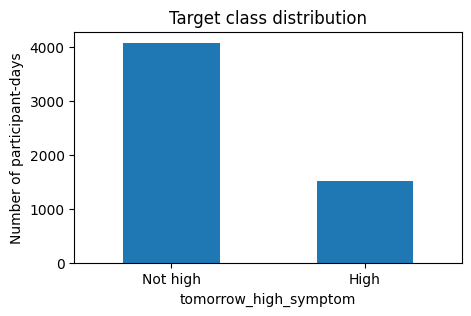

In [ ]:
target_balance = target_table["tomorrow_high_symptom"].value_counts(normalize=True)
display(target_balance)

plt.figure(figsize=(5, 3))
target_table["tomorrow_high_symptom"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Not high", "High"], rotation=0)
plt.ylabel("Number of participant-days")
plt.title("Target class distribution")
plt.show()


### Target interpretation

The target is imbalanced because most days are not high-symptom days.  
That means accuracy alone is not enough. A model could predict “not high” most of the time and still look accurate.

For this reason, the main metrics are:

- **PR-AUC**, because this is an imbalanced risk-ranking problem  
- **F1**, because it balances precision and recall  
- **Recall**, because missing high-symptom days is important  
- **Precision**, because too many false alerts would reduce user trust


---

# 4. Feature engineering

This section builds feature versions one step at a time.

The purpose is to check whether each added wearable signal improves the model enough to justify the extra processing cost.

| Version | Feature set |
|---|---|
| V1 | sleep + activity + phase |
| V2 | V1 + resting heart rate |
| V3 | V2 + HRV |
| V4 | V3 + wrist temperature |

All features here are tested as an experiment, but they will only be kept if they improve the model, otherwise they'll be rejected because they add extra processing without enough benefit.


## 4.1 V1 baseline: sleep + activity + phase


In [ ]:
ml_df_v1 = target_table.merge(
    sleep,
    on=key,
    how="left",
    suffixes=("", "_sleep")
)

ml_df_v1 = ml_df_v1.merge(
    am,
    on=key,
    how="left",
    suffixes=("", "_activity")
)

print("V1 merged shape:", ml_df_v1.shape)

missing_v1 = ml_df_v1.isnull().sum().sort_values(ascending=False)
display(missing_v1[missing_v1 > 0])


V1 merged shape: (5971, 22)


,0
composition_score,2246
duration_score,2246
sedentary,2192
deep_sleep_in_minutes,575
revitalization_score,571
overall_score,571
restlessness,571
resting_heart_rate,571
timestamp,571
is_weekend_sleep,571


In [ ]:
model_cols_v1 = [
    "id",
    "study_interval",
    "day_in_study",
    "is_weekend",
    "phase",

    # sleep features
    "overall_score",
    "revitalization_score",
    "deep_sleep_in_minutes",
    "resting_heart_rate",
    "restlessness",

    # activity features
    "lightly",
    "moderately",
    "very",

    # target
    "tomorrow_high_symptom"
]

model_df_v1_raw = ml_df_v1[model_cols_v1].copy()
display(model_df_v1_raw.head())


,id,study_interval,day_in_study,is_weekend,phase,overall_score,revitalization_score,deep_sleep_in_minutes,resting_heart_rate,restlessness,lightly,moderately,very,tomorrow_high_symptom
0,1,2022,1,True,Follicular,NaN,NaN,NaN,NaN,NaN,64.0,0.0,0.0,1
1,1,2022,2,False,Follicular,NaN,NaN,NaN,NaN,NaN,74.0,0.0,0.0,1
2,1,2022,3,False,Follicular,NaN,NaN,NaN,NaN,NaN,134.0,18.0,7.0,1
3,1,2022,4,False,Fertility,80.0,22.0,93.0,84.0,0.056404,86.0,0.0,0.0,0
4,1,2022,5,False,Fertility,NaN,NaN,NaN,NaN,NaN,10.0,0.0,0.0,0


V1 is the baseline wearable model. It only uses simple daily sleep and activity features plus phase/weekend context.



## 4.2 V2: add resting heart rate

`resting_heart_rate.csv` has multiple rows per participant-day, so it is aggregated into daily summary features first.


In [ ]:
rhr_daily = (
    rhr
    .groupby(key)
    .agg(
        rhr_mean=("value", "mean"),
        rhr_min=("value", "min"),
        rhr_max=("value", "max"),
        rhr_std=("value", "std"),
        rhr_error_mean=("error", "mean")
    )
    .reset_index()
)

rhr_daily["rhr_std"] = rhr_daily["rhr_std"].fillna(0)

display(rhr_daily.head())
print("RHR daily shape:", rhr_daily.shape)


,id,study_interval,day_in_study,rhr_mean,rhr_min,rhr_max,rhr_std,rhr_error_mean
0,1,2022,1,74.785346,74.785346,74.785346,0.0,100.000000
1,1,2022,2,80.407307,80.407307,80.407307,0.0,29.833838
2,1,2022,3,84.686869,84.686869,84.686869,0.0,24.267298
3,1,2022,4,83.852219,83.852219,83.852219,0.0,10.344703
4,1,2022,5,0.000000,0.000000,0.000000,0.0,0.000000


RHR daily shape: (5659, 8)


In [ ]:
ml_df_v2 = ml_df_v1.merge(
    rhr_daily,
    on=key,
    how="left"
)

model_cols_v2 = model_cols_v1[:-1] + [
    "rhr_mean",
    "rhr_min",
    "rhr_max",
    "rhr_std",
    "rhr_error_mean",
    "tomorrow_high_symptom"
]

model_df_v2_raw = ml_df_v2[model_cols_v2].copy()

print("V2 merged shape:", ml_df_v2.shape)
display(model_df_v2_raw.isnull().sum().sort_values(ascending=False).head(15))


V2 merged shape: (5971, 27)


,0
deep_sleep_in_minutes,575
revitalization_score,571
resting_heart_rate,571
restlessness,571
overall_score,571
very,178
lightly,178
moderately,178
phase,1
id,0


## 4.3 V3: add heart rate variability

HRV is relevant because it can reflect stress, recovery, and autonomic nervous system activity.  
Like RHR, it is aggregated into daily features before modelling.


In [ ]:
hrv_daily = (
    hrv
    .groupby(key)
    .agg(
        hrv_rmssd_mean=("rmssd", "mean"),
        hrv_rmssd_min=("rmssd", "min"),
        hrv_rmssd_max=("rmssd", "max"),
        hrv_rmssd_std=("rmssd", "std"),
        hrv_coverage_mean=("coverage", "mean"),
        hrv_lf_mean=("low_frequency", "mean"),
        hrv_hf_mean=("high_frequency", "mean")
    )
    .reset_index()
)

hrv_daily["hrv_rmssd_std"] = hrv_daily["hrv_rmssd_std"].fillna(0)

display(hrv_daily.head())
print("HRV daily shape:", hrv_daily.shape)


,id,study_interval,day_in_study,hrv_rmssd_mean,hrv_rmssd_min,hrv_rmssd_max,hrv_rmssd_std,hrv_coverage_mean,hrv_lf_mean,hrv_hf_mean
0,2,2022,7,40.505200,37.058,42.649,2.114743,0.936000,581.759000,354.807600
1,2,2022,8,46.127240,16.396,73.581,11.736847,0.966779,789.802279,514.074221
2,2,2022,9,45.416714,19.175,67.859,11.206875,0.970962,787.655714,491.226638
3,2,2022,10,44.951217,21.826,69.776,10.416914,0.973565,861.202326,486.741424
4,2,2022,11,39.762764,16.807,76.482,9.123668,0.967821,671.228358,363.367651


HRV daily shape: (4839, 10)


In [ ]:
ml_df_v3 = ml_df_v2.merge(
    hrv_daily,
    on=key,
    how="left"
)

model_cols_v3 = model_cols_v2[:-1] + [
    "hrv_rmssd_mean",
    "hrv_rmssd_min",
    "hrv_rmssd_max",
    "hrv_rmssd_std",
    "hrv_coverage_mean",
    "hrv_lf_mean",
    "hrv_hf_mean",
    "tomorrow_high_symptom"
]

model_df_v3_raw = ml_df_v3[model_cols_v3].copy()

print("V3 merged shape:", ml_df_v3.shape)
display(model_df_v3_raw.isnull().sum().sort_values(ascending=False).head(20))


V3 merged shape: (5971, 34)


,0
hrv_hf_mean,823
hrv_rmssd_std,823
hrv_coverage_mean,823
hrv_rmssd_mean,823
hrv_rmssd_max,823
hrv_rmssd_min,823
hrv_lf_mean,823
deep_sleep_in_minutes,575
restlessness,571
overall_score,571


## 4.4 V4: add wrist temperature

Wrist temperature is biologically relevant to menstrual health, so it is tested in V4.


In [ ]:
wt_daily = (
    wt
    .groupby(key)
    .agg(
        wt_mean=("temperature_diff_from_baseline", "mean"),
        wt_min=("temperature_diff_from_baseline", "min"),
        wt_max=("temperature_diff_from_baseline", "max"),
        wt_std=("temperature_diff_from_baseline", "std"),
        wt_median=("temperature_diff_from_baseline", "median")
    )
    .reset_index()
)

wt_daily["wt_std"] = wt_daily["wt_std"].fillna(0)

display(wt_daily.head())
print("WT daily shape:", wt_daily.shape)


,id,study_interval,day_in_study,wt_mean,wt_min,wt_max,wt_std,wt_median
0,1,2022,3,-2.410090,-9.591087,2.508913,2.954392,-2.278587
1,1,2022,4,-2.198042,-9.308072,2.056928,2.762839,-1.430572
2,1,2022,6,-1.609594,-9.048197,1.781803,2.942531,-0.385697
3,1,2022,7,-0.877416,-8.916627,4.473373,1.389731,-0.636627
4,1,2022,9,-0.642556,-8.995056,1.769944,1.598276,-0.285056


WT daily shape: (5138, 8)


In [ ]:
ml_df_v4 = ml_df_v3.merge(
    wt_daily,
    on=key,
    how="left"
)

model_cols_v4 = model_cols_v3[:-1] + [
    "wt_mean",
    "wt_min",
    "wt_max",
    "wt_std",
    "wt_median",
    "tomorrow_high_symptom"
]

model_df_v4_raw = ml_df_v4[model_cols_v4].copy()

print("V4 merged shape:", ml_df_v4.shape)
display(model_df_v4_raw.isnull().sum().sort_values(ascending=False).head(25))


V4 merged shape: (5971, 39)


,0
hrv_hf_mean,823
hrv_lf_mean,823
hrv_coverage_mean,823
hrv_rmssd_min,823
hrv_rmssd_max,823
hrv_rmssd_std,823
hrv_rmssd_mean,823
deep_sleep_in_minutes,575
resting_heart_rate,571
overall_score,571


In [ ]:
feature_version_summary = pd.DataFrame([
    {"version": "V1 baseline", "feature_count_before_encoding": len(model_cols_v1) - 4, "description": "sleep + activity + phase"},
    {"version": "V2 + RHR", "feature_count_before_encoding": len(model_cols_v2) - 4, "description": "V1 + resting heart rate"},
    {"version": "V3 + HRV", "feature_count_before_encoding": len(model_cols_v3) - 4, "description": "V2 + HRV"},
    {"version": "V4 + WT", "feature_count_before_encoding": len(model_cols_v4) - 4, "description": "V3 + wrist temperature"},
])

display(feature_version_summary)


,version,feature_count_before_encoding,description
0,V1 baseline,10,sleep + activity + phase
1,V2 + RHR,15,V1 + resting heart rate
2,V3 + HRV,22,V2 + HRV
3,V4 + WT,27,V3 + wrist temperature


---

### **5. Modelling helper functions**

This section defines the core logic for the classification pipeline. To ensure the model is robust and suitable for an Edge AI context, I implement several best practices:

*   **Scikit-Learn Pipelines**: I encapsulate preprocessing (imputation, scaling, encoding) and the estimator into a single `Pipeline` object. This ensures consistency between training and inference.
*   **Data Leakage Prevention**: By using `SimpleImputer` and `StandardScaler` **inside** the pipeline, I ensure that parameters like the median or mean are calculated only on training folds and never 'leak' information from the test set.
*   **GroupKFold Validation**: Since the dataset contains multiple days of data for the same participants, I use `GroupKFold`. This ensures that a participant's data is never split across the training and testing sets, providing a more realistic estimate of how the model performs on new, unseen users.
*   **Balanced Class Weights**: Given the imbalance in the target (roughly 27% high-symptom days), I use `class_weight='balanced'` to prevent the model from becoming biased toward the majority 'not-high' class.

In [ ]:
def prepare_xy_groups(model_df, target_col="tomorrow_high_symptom"):
    """Create X, y, and groups without manually imputing missing values."""
    df = model_df.copy()

    # Convert boolean context into a numeric feature.
    if "is_weekend" in df.columns:
        df["is_weekend"] = df["is_weekend"].astype(int)

    X = df.drop(
        columns=[
            target_col,
            "id",
            "study_interval",
            "day_in_study"
        ]
    )

    y = df[target_col]
    groups = df["id"]

    return X, y, groups


def build_preprocessor(X, scale_numeric=True):
    """Build preprocessing for numeric and categorical columns."""
    categorical_cols = ["phase"] if "phase" in X.columns else []
    numeric_cols = [col for col in X.columns if col not in categorical_cols]

    if scale_numeric:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ])

    return preprocessor


def make_model_pipeline(model_name, X, max_depth=None):
    """Create a full preprocessing + model pipeline."""
    if model_name == "Logistic Regression":
        return Pipeline([
            ("preprocess", build_preprocessor(X, scale_numeric=True)),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "Decision Tree":
        return Pipeline([
            ("preprocess", build_preprocessor(X, scale_numeric=False)),
            ("model", DecisionTreeClassifier(
                max_depth=max_depth,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "Random Forest":
        return Pipeline([
            ("preprocess", build_preprocessor(X, scale_numeric=False)),
            ("model", RandomForestClassifier(
                n_estimators=50,
                max_depth=max_depth,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    raise ValueError(f"Unknown model name: {model_name}")


In [ ]:
cv = GroupKFold(n_splits=5)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "pr_auc": "average_precision"
}


def summarise_cv_scores(scores):
    """Return mean and std for the main metrics from cross_validate output."""
    return {
        "accuracy": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "precision": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),
        "recall": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "f1": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "pr_auc": scores["test_pr_auc"].mean(),
        "pr_auc_std": scores["test_pr_auc"].std()
    }


def evaluate_version(model_df, version_name):
    """Evaluate LR, Decision Trees, and Random Forests for one feature version."""
    X, y, groups = prepare_xy_groups(model_df)

    results = []

    # Logistic Regression.
    model = make_model_pipeline("Logistic Regression", X)
    scores = cross_validate(
        model,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    row = {
        "version": version_name,
        "model": "Logistic Regression",
        "max_depth": None
    }
    row.update(summarise_cv_scores(scores))
    results.append(row)

    # Decision Trees.
    # This compact grid tests shallow, moderate, and deeper trees without making the notebook too slow.
    for depth in [1, 2, 3, 4, 5, 6, 8, 10]:
        model = make_model_pipeline("Decision Tree", X, max_depth=depth)

        scores = cross_validate(
            model,
            X,
            y,
            groups=groups,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )

        row = {
            "version": version_name,
            "model": "Decision Tree",
            "max_depth": depth
        }
        row.update(summarise_cv_scores(scores))
        results.append(row)

    # Random Forests.
    # Depth 1 is skipped here because a forest of depth-1 stumps is usually too restricted.
    for depth in [2, 3, 4, 5, 6, 8]:
        model = make_model_pipeline("Random Forest", X, max_depth=depth)

        scores = cross_validate(
            model,
            X,
            y,
            groups=groups,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )

        row = {
            "version": version_name,
            "model": "Random Forest",
            "max_depth": depth
        }
        row.update(summarise_cv_scores(scores))
        results.append(row)

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="pr_auc", ascending=False).reset_index(drop=True)

    return results_df


---

# 6. Naive baseline

A naive baseline is useful because it shows what happens if we do **no real ML**.

Here the naive baseline always predicts:

```text
tomorrow_high_symptom = 0
```

This can produce reasonable accuracy because the dataset is imbalanced, but it should have zero recall for high-symptom days.


In [ ]:
X_v1_raw, y_v1_raw, groups_v1_raw = prepare_xy_groups(model_df_v1_raw)

y_naive = np.zeros_like(y_v1_raw)

naive_baseline = pd.DataFrame([{
    "model": "Naive majority baseline",
    "accuracy": accuracy_score(y_v1_raw, y_naive),
    "precision": precision_score(y_v1_raw, y_naive, zero_division=0),
    "recall": recall_score(y_v1_raw, y_naive, zero_division=0),
    "f1": f1_score(y_v1_raw, y_naive, zero_division=0),
    "pr_auc_reference": y_v1_raw.mean()
}])

display(naive_baseline.round(3))


,model,accuracy,precision,recall,f1,pr_auc_reference
0,Naive majority baseline,0.737,0.0,0.0,0.0,0.263


### Naive baseline interpretation

The naive model has high-looking accuracy because most days are not high-symptom days.  
However, it cannot detect any actual high-symptom days, so recall and F1 should be zero.

This is why the real models are judged mainly using PR-AUC, F1, precision, and recall rather than accuracy alone.


---

# 7. Evaluate all feature versions

This is the main experiment section.

For each feature version, I compare:
- Logistic Regression
- Decision Trees with different depths
- Random Forests with constrained depths

The models are evaluated using 5-fold `GroupKFold` by participant.


In [ ]:
compare_v1 = evaluate_version(model_df_v1_raw, "V1 baseline")
display(compare_v1.round(3))


,version,model,max_depth,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,pr_auc,pr_auc_std
0,V1 baseline,Logistic Regression,NaN,0.576,0.088,0.369,0.063,0.813,0.114,0.503,0.065,0.444,0.079
1,V1 baseline,Random Forest,4.0,0.582,0.097,0.376,0.063,0.837,0.110,0.515,0.064,0.431,0.098
2,V1 baseline,Random Forest,5.0,0.597,0.084,0.382,0.061,0.814,0.091,0.517,0.063,0.430,0.102
3,V1 baseline,Random Forest,6.0,0.591,0.083,0.373,0.054,0.773,0.088,0.500,0.052,0.429,0.097
4,V1 baseline,Random Forest,3.0,0.574,0.106,0.376,0.067,0.850,0.122,0.515,0.064,0.429,0.100
5,V1 baseline,Random Forest,2.0,0.555,0.094,0.368,0.055,0.915,0.082,0.522,0.059,0.428,0.102
6,V1 baseline,Random Forest,8.0,0.608,0.077,0.380,0.054,0.714,0.093,0.490,0.045,0.423,0.087
7,V1 baseline,Decision Tree,5.0,0.617,0.037,0.380,0.049,0.702,0.036,0.491,0.041,0.423,0.092
8,V1 baseline,Decision Tree,4.0,0.564,0.099,0.367,0.053,0.845,0.085,0.507,0.052,0.420,0.081
9,V1 baseline,Decision Tree,6.0,0.604,0.029,0.367,0.038,0.689,0.064,0.476,0.036,0.411,0.069


### **V1 interpretation**

The V1 baseline used only the initial passive features: sleep, activity, weekend status, and menstrual phase. This version gives a starting point before adding extra physiological signals.

The best model by PR-AUC was Logistic Regression, with a PR-AUC of 0.444 and F1-score of 0.503. This shows that even the simple baseline features contain some useful signal for predicting next-day high symptom risk. However, the precision is low at 0.369, meaning many high-risk predictions are false alerts. The recall is much higher at 0.813, so the model is better at catching high-symptom days than avoiding false positives.

Some tree-based models achieved slightly higher F1-scores, such as Decision Tree depth 1/2 and Random Forest depth 2, but their PR-AUC scores were lower. Since PR-AUC is more suitable for this imbalanced risk-prediction task, Logistic Regression is kept as the strongest V1 baseline model.

Overall, V1 provides a useful baseline, but the performance is still limited. This supports the need to add more physiological features such as resting heart rate and HRV.


In [ ]:
compare_v2 = evaluate_version(model_df_v2_raw, "V2 + RHR")
display(compare_v2.round(3))


,version,model,max_depth,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,pr_auc,pr_auc_std
0,V2 + RHR,Logistic Regression,NaN,0.639,0.033,0.414,0.047,0.890,0.085,0.562,0.045,0.483,0.090
1,V2 + RHR,Decision Tree,4.0,0.656,0.039,0.420,0.053,0.834,0.102,0.558,0.063,0.477,0.080
2,V2 + RHR,Decision Tree,5.0,0.652,0.049,0.420,0.060,0.799,0.074,0.547,0.054,0.465,0.081
3,V2 + RHR,Decision Tree,6.0,0.647,0.041,0.411,0.047,0.767,0.075,0.532,0.040,0.452,0.064
4,V2 + RHR,Random Forest,6.0,0.643,0.036,0.418,0.048,0.889,0.050,0.566,0.040,0.451,0.071
5,V2 + RHR,Random Forest,8.0,0.657,0.031,0.423,0.048,0.827,0.073,0.557,0.046,0.448,0.069
6,V2 + RHR,Random Forest,3.0,0.633,0.038,0.418,0.047,0.982,0.028,0.584,0.041,0.446,0.074
7,V2 + RHR,Random Forest,5.0,0.636,0.036,0.418,0.043,0.945,0.057,0.576,0.031,0.445,0.067
8,V2 + RHR,Random Forest,4.0,0.632,0.037,0.417,0.046,0.972,0.048,0.581,0.037,0.443,0.063
9,V2 + RHR,Random Forest,2.0,0.628,0.031,0.414,0.041,0.997,0.005,0.584,0.041,0.442,0.077


### **V2 interpretation**

In V2, I added resting heart rate features to the baseline feature set. This clearly improved the results compared with V1.

Logistic Regression remained the best model by PR-AUC, increasing from 0.444 in V1 to 0.483 in V2. The F1-score also improved from 0.503 to 0.562, and recall increased from 0.813 to 0.890. This shows that resting heart rate adds useful physiological information for predicting next-day symptom risk.

The Decision Tree with depth 4 also performed well, with a PR-AUC of 0.477 and F1-score of 0.558. This is close to Logistic Regression, but Logistic Regression still ranks high-risk days slightly better overall. Some Random Forest models achieved higher F1-scores, but their PR-AUC values were lower, meaning they were more sensitive but less reliable for ranking risk.

Overall, V2 shows that resting heart rate is one of the most useful added features in this project. It improved performance without making the model very complex.


In [ ]:
compare_v3 = evaluate_version(model_df_v3_raw, "V3 + HRV")
display(compare_v3.round(3))


,version,model,max_depth,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,pr_auc,pr_auc_std
0,V3 + HRV,Logistic Regression,NaN,0.653,0.036,0.425,0.051,0.864,0.066,0.566,0.042,0.485,0.097
1,V3 + HRV,Random Forest,4.0,0.631,0.040,0.412,0.050,0.922,0.072,0.567,0.047,0.447,0.102
2,V3 + HRV,Random Forest,3.0,0.627,0.031,0.413,0.042,0.991,0.011,0.582,0.042,0.445,0.093
3,V3 + HRV,Random Forest,5.0,0.630,0.043,0.407,0.054,0.866,0.051,0.551,0.050,0.444,0.100
4,V3 + HRV,Decision Tree,3.0,0.654,0.019,0.410,0.041,0.756,0.222,0.520,0.083,0.442,0.083
5,V3 + HRV,Decision Tree,5.0,0.652,0.007,0.412,0.035,0.801,0.110,0.544,0.053,0.440,0.092
6,V3 + HRV,Random Forest,6.0,0.634,0.045,0.406,0.058,0.818,0.068,0.539,0.052,0.439,0.096
7,V3 + HRV,Random Forest,8.0,0.656,0.048,0.419,0.069,0.729,0.114,0.524,0.056,0.439,0.104
8,V3 + HRV,Decision Tree,4.0,0.644,0.030,0.408,0.044,0.808,0.136,0.540,0.063,0.437,0.079
9,V3 + HRV,Decision Tree,6.0,0.667,0.030,0.426,0.049,0.787,0.070,0.552,0.056,0.434,0.086


### **V3 interpretation**

In V3, I added HRV features on top of the V2 feature set. Logistic Regression again achieved the best PR-AUC, with a score of 0.485. This is a small improvement over V2, where PR-AUC was 0.483.

The improvement from HRV is much smaller than the improvement seen when resting heart rate was added. However, V3 still gives the best overall result so far. The F1-score is 0.566, and recall is 0.864, meaning the model still detects many high-symptom days while keeping a slightly better balance than earlier versions.

Some Random Forest and Decision Tree models achieved higher F1-scores, especially the shallower models with very high recall. However, their PR-AUC values were lower than Logistic Regression. This means they may produce more high-risk alerts, but they are not as good at ranking true high-risk days overall.

Overall, V3 is selected as the best current version because it has the strongest PR-AUC and remains simple, interpretable, and edge-friendly.


In [ ]:
compare_v4 = evaluate_version(model_df_v4_raw, "V4 + WT")
display(compare_v4.round(3))


,version,model,max_depth,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,pr_auc,pr_auc_std
0,V4 + WT,Logistic Regression,NaN,0.653,0.034,0.424,0.048,0.854,0.058,0.563,0.037,0.448,0.064
1,V4 + WT,Decision Tree,3.0,0.653,0.019,0.410,0.041,0.757,0.222,0.520,0.083,0.445,0.090
2,V4 + WT,Random Forest,2.0,0.630,0.033,0.415,0.042,0.985,0.026,0.582,0.040,0.443,0.095
3,V4 + WT,Random Forest,4.0,0.631,0.043,0.410,0.053,0.885,0.107,0.556,0.051,0.435,0.099
4,V4 + WT,Random Forest,3.0,0.630,0.033,0.415,0.042,0.975,0.034,0.580,0.039,0.434,0.091
5,V4 + WT,Decision Tree,4.0,0.641,0.033,0.406,0.048,0.812,0.126,0.539,0.064,0.433,0.072
6,V4 + WT,Random Forest,5.0,0.631,0.042,0.409,0.054,0.888,0.097,0.557,0.055,0.433,0.095
7,V4 + WT,Decision Tree,2.0,0.625,0.031,0.412,0.041,0.997,0.005,0.582,0.041,0.432,0.071
8,V4 + WT,Random Forest,6.0,0.631,0.041,0.405,0.054,0.830,0.071,0.541,0.048,0.426,0.087
9,V4 + WT,Decision Tree,5.0,0.650,0.017,0.410,0.044,0.797,0.125,0.541,0.064,0.422,0.063


### **V4 interpretation**

In V3, I added HRV features. Logistic Regression again achieved the best PR-AUC, with a score of 0.485. This is a small improvement over V2, where PR-AUC was 0.483.

The improvement from HRV is much smaller than the improvement seen when resting heart rate was added. However, V3 still gives the best overall result so far. The F1-score is 0.566, and recall is 0.864, meaning the model still detects many high-symptom days while keeping a slightly better balance than earlier versions.

Some Random Forest and Decision Tree models achieved higher F1-scores, especially the shallower models with very high recall. However, their PR-AUC values were lower than Logistic Regression. This means they may produce more high-risk alerts, but they are not as good at ranking true high-risk days overall.

Overall, V3 is selected as the best current version because it has the strongest PR-AUC and remains simple, interpretable, and edge-friendly.


---

# 8. Compare best models across versions


In [ ]:
best_versions = pd.concat([
    compare_v1.head(1),
    compare_v2.head(1),
    compare_v3.head(1),
    compare_v4.head(1)
], ignore_index=True)

display(best_versions.round(3))


,version,model,max_depth,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,pr_auc,pr_auc_std
0,V1 baseline,Logistic Regression,NaN,0.576,0.088,0.369,0.063,0.813,0.114,0.503,0.065,0.444,0.079
1,V2 + RHR,Logistic Regression,NaN,0.639,0.033,0.414,0.047,0.890,0.085,0.562,0.045,0.483,0.090
2,V3 + HRV,Logistic Regression,NaN,0.653,0.036,0.425,0.051,0.864,0.066,0.566,0.042,0.485,0.097
3,V4 + WT,Logistic Regression,NaN,0.653,0.034,0.424,0.048,0.854,0.058,0.563,0.037,0.448,0.064


## Best models across feature versions

I this table I compare the best model from each feature version. In all versions, Logistic Regression was the best model by PR-AUC.

The results show a clear improvement from V1 to V2 after adding resting heart rate. PR-AUC increased from 0.444 to 0.483, and F1-score increased from 0.503 to 0.562. This was the largest performance improvement in the project.

Adding HRV in V3 gave a smaller additional improvement. PR-AUC increased slightly from 0.483 to 0.485, and F1-score increased from 0.562 to 0.566. This suggests HRV added some extra information, but not as much as resting heart rate.

Adding wrist temperature in V4 reduced PR-AUC from 0.485 to 0.448. Because PR-AUC is the main metric for this imbalanced risk-prediction task, V4 was rejected.

Overall, I selected V3 Logistic Regression as the best model version because it achieved the highest PR-AUC while remaining simple and suitable for edge deployment.

In [ ]:
all_model_results = pd.concat(
    [compare_v1, compare_v2, compare_v3, compare_v4],
    ignore_index=True
)

best_overall = all_model_results.sort_values(
    by="pr_auc",
    ascending=False
).head(1)

display(best_overall.round(3))


,version,model,max_depth,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,pr_auc,pr_auc_std
30,V3 + HRV,Logistic Regression,NaN,0.653,0.036,0.425,0.051,0.864,0.066,0.566,0.042,0.485,0.097


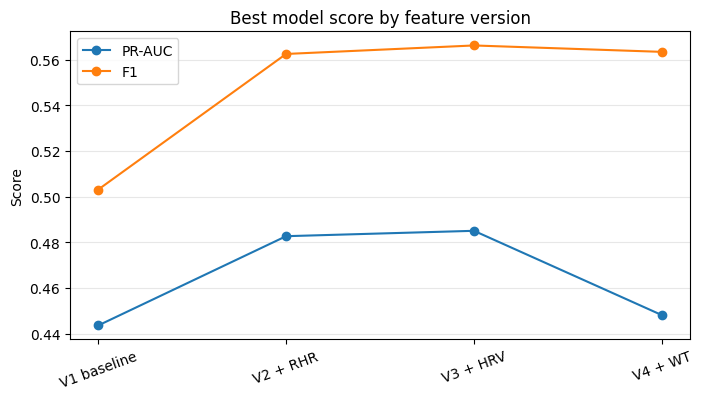

In [ ]:
# Visual comparison of the best model from each feature version.
plt.figure(figsize=(8, 4))
plt.plot(best_versions["version"], best_versions["pr_auc"], marker="o", label="PR-AUC")
plt.plot(best_versions["version"], best_versions["f1"], marker="o", label="F1")
plt.xticks(rotation=20)
plt.ylabel("Score")
plt.title("Best model score by feature version")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


### Version comparison interpretation

The plot shows how PR-AUC and F1-score changed as more feature groups were added.

The biggest improvement happens between V1 and V2. This confirms that resting heart rate was the most useful added physiological feature. F1-score increased strongly, and PR-AUC also improved.

From V2 to V3, the improvement is smaller. HRV slightly improves both PR-AUC and F1-score, but the gain is marginal. This still supports keeping HRV because it gives the best overall version.

From V3 to V4, PR-AUC drops sharply after adding wrist temperature. This shows that wrist temperature did not help in the current feature-engineering setup. Even though the F1-score stays close to V3, the drop in PR-AUC means the model became worse at ranking high-risk days.

The plot shows the final decision to select V3 as the best feature version and reject V4. It also shows an important Edge AI lesson: adding more sensor data is not always beneficial if it increases processing cost without improving predictive performance.


---

# 9. Edge AI data reduction: bandwidth and energy-cost

For my project, the strongest saving bandwidth and energy cost evidence is local aggregation:

```text
raw wearable readings → daily summary features
```

This means the edge device doesn't need to send raw sensor streams to the cloud.  
The final selected V3 model uses RHR and HRV features, so those are the most relevant for final bandwidth saving.


In [ ]:
def dataframe_memory_mb(df):
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

data_reduction_summary = pd.DataFrame([
    {
        "table": "resting_heart_rate",
        "used_in_final_model": True,
        "raw_rows": len(rhr),
        "daily_feature_rows": len(rhr_daily),
        "row_reduction_ratio": len(rhr) / len(rhr_daily),
        "raw_size_mb": dataframe_memory_mb(rhr),
        "daily_feature_size_mb": dataframe_memory_mb(rhr_daily)
    },
    {
        "table": "heart_rate_variability",
        "used_in_final_model": True,
        "raw_rows": len(hrv),
        "daily_feature_rows": len(hrv_daily),
        "row_reduction_ratio": len(hrv) / len(hrv_daily),
        "raw_size_mb": dataframe_memory_mb(hrv),
        "daily_feature_size_mb": dataframe_memory_mb(hrv_daily)
    },
    {
        "table": "wrist_temperature",
        "used_in_final_model": False,
        "raw_rows": len(wt),
        "daily_feature_rows": len(wt_daily),
        "row_reduction_ratio": len(wt) / len(wt_daily),
        "raw_size_mb": dataframe_memory_mb(wt),
        "daily_feature_size_mb": dataframe_memory_mb(wt_daily)
    }
])

data_reduction_summary["size_reduction_ratio"] = (
    data_reduction_summary["raw_size_mb"] /
    data_reduction_summary["daily_feature_size_mb"]
)

data_reduction_summary["bandwidth_saved_percent"] = (
    1 - data_reduction_summary["daily_feature_size_mb"] / data_reduction_summary["raw_size_mb"]
) * 100

display(data_reduction_summary.round(3))


,table,used_in_final_model,raw_rows,daily_feature_rows,row_reduction_ratio,raw_size_mb,daily_feature_size_mb,size_reduction_ratio,bandwidth_saved_percent
0,resting_heart_rate,True,13737,5659,2.427,0.537,0.346,1.555,35.687
1,heart_rate_variability,True,436262,4839,90.155,47.430,0.369,128.428,99.221
2,wrist_temperature,False,6856019,5138,1334.375,588.457,0.314,1875.712,99.947


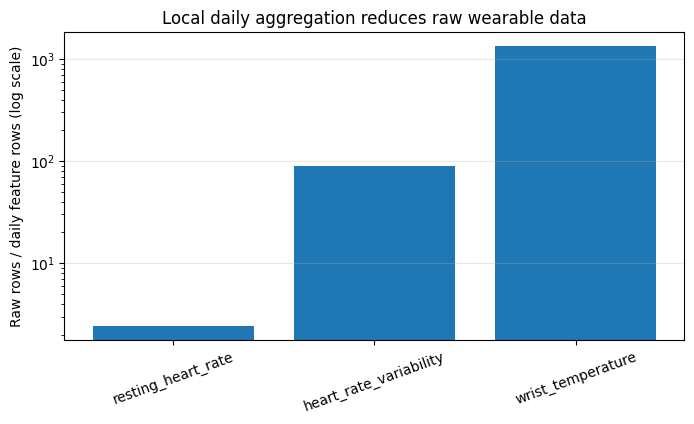

In [ ]:
# Plot the row-reduction ratio. Log scale is used because wrist temperature is much larger.
plt.figure(figsize=(8, 4))
plt.bar(data_reduction_summary["table"], data_reduction_summary["row_reduction_ratio"])
plt.yscale("log")
plt.ylabel("Raw rows / daily feature rows (log scale)")
plt.title("Local daily aggregation reduces raw wearable data")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()


## Bandwidth and energy interpretation

This table shows how much raw wearable data can be reduced when sensor readings are processed locally into daily summary features before modelling.

The strongest bandwidth saving comes from the high-frequency sensor tables. For example, heart_rate_variability is reduced from 436,262 raw rows to 4,839 daily feature rows, giving a row reduction ratio of about 90×. In memory terms, this reduces the data size from 47.43 MB to 0.369 MB, which is about 99.2% bandwidth saving.

The largest reduction is seen for wrist_temperature, which drops from 6,856,019 raw rows to 5,138 daily rows. This gives a very large row reduction ratio of about 1334× and a memory-size reduction from 588.46 MB to 0.314 MB, equal to about 99.95% bandwidth saving. However, wrist temperature was not kept in the final selected model because it reduced PR-AUC in V4. Therefore, it is best discussed as an example of a heavy sensor stream that was tested but rejected because it did not justify its processing cost.

For the final selected V3 model, the most relevant tables are resting_heart_rate and heart_rate_variability, because both are used in the final feature set. resting_heart_rate has a smaller reduction than HRV, but still reduces from 13,737 raw rows to 5,659 daily feature rows, saving about 35.7% of data size. HRV gives a much stronger reduction, saving about 99.2% of data size.

The bar chart supports this result visually. Since it uses a log scale, it shows that HRV and wrist temperature have much higher raw-to-daily reduction ratios than resting heart rate. This supports the Edge AI idea that local aggregation can substantially reduce the amount of raw wearable data that needs to be transmitted.

---

# 10. Threshold analysis using out-of-fold predictions

`cross_validate()` compares models.  
`cross_val_predict()` is used here to create out-of-fold probabilities for threshold testing.

This is cleaner than testing thresholds on predictions from a model trained on the full dataset, because each out-of-fold probability is produced by a model that did not train on that row.

Also, threshold testing is only done for shortlisted models, not every single model.


In [ ]:
# Select the best version by PR-AUC.
selected_version_name = best_overall.iloc[0]["version"]
print("Selected version for threshold analysis:", selected_version_name)

version_to_df = {
    "V1 baseline": model_df_v1_raw,
    "V2 + RHR": model_df_v2_raw,
    "V3 + HRV": model_df_v3_raw,
    "V4 + WT": model_df_v4_raw
}

selected_model_df = version_to_df[selected_version_name]
X_selected, y_selected, groups_selected = prepare_xy_groups(selected_model_df)

# Shortlist the top three models from the selected version.
shortlisted_models = (
    all_model_results[all_model_results["version"] == selected_version_name]
    .sort_values(by="pr_auc", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

display(shortlisted_models.round(3))


Selected version for threshold analysis: V3 + HRV


,version,model,max_depth,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,pr_auc,pr_auc_std
0,V3 + HRV,Logistic Regression,NaN,0.653,0.036,0.425,0.051,0.864,0.066,0.566,0.042,0.485,0.097
1,V3 + HRV,Random Forest,4.0,0.631,0.040,0.412,0.050,0.922,0.072,0.567,0.047,0.447,0.102
2,V3 + HRV,Random Forest,3.0,0.627,0.031,0.413,0.042,0.991,0.011,0.582,0.042,0.445,0.093


In [ ]:
threshold_grid = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_rows = []

for _, row in shortlisted_models.iterrows():
    model_name = row["model"]
    max_depth = row["max_depth"]
    max_depth_value = None if pd.isna(max_depth) else int(max_depth)

    model = make_model_pipeline(model_name, X_selected, max_depth=max_depth_value)

    # Out-of-fold probabilities.
    oof_probs = cross_val_predict(
        model,
        X_selected,
        y_selected,
        groups=groups_selected,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    for threshold in threshold_grid:
        preds = (oof_probs >= threshold).astype(int)

        threshold_rows.append({
            "version": selected_version_name,
            "model": model_name,
            "max_depth": max_depth_value,
            "threshold": threshold,
            "precision": precision_score(y_selected, preds, zero_division=0),
            "recall": recall_score(y_selected, preds, zero_division=0),
            "f1": f1_score(y_selected, preds, zero_division=0)
        })

threshold_results = pd.DataFrame(threshold_rows)

display(threshold_results.round(3))


,version,model,max_depth,threshold,precision,recall,f1
0,V3 + HRV,Logistic Regression,NaN,0.30,0.410,0.972,0.577
1,V3 + HRV,Logistic Regression,NaN,0.35,0.413,0.962,0.578
2,V3 + HRV,Logistic Regression,NaN,0.40,0.415,0.946,0.577
3,V3 + HRV,Logistic Regression,NaN,0.45,0.416,0.911,0.571
4,V3 + HRV,Logistic Regression,NaN,0.50,0.422,0.862,0.567
5,V3 + HRV,Logistic Regression,NaN,0.55,0.429,0.789,0.556
6,V3 + HRV,Logistic Regression,NaN,0.60,0.448,0.690,0.543
7,V3 + HRV,Logistic Regression,NaN,0.65,0.475,0.555,0.512
8,V3 + HRV,Logistic Regression,NaN,0.70,0.494,0.412,0.449
9,V3 + HRV,Random Forest,4.0,0.30,0.413,0.997,0.584


In [ ]:
best_thresholds = (
    threshold_results
    .sort_values(by="f1", ascending=False)
    .groupby(["model", "max_depth"], dropna=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_thresholds.round(3))


,version,model,max_depth,threshold,precision,recall,f1
0,V3 + HRV,Random Forest,3.0,0.45,0.414,0.997,0.585
1,V3 + HRV,Random Forest,4.0,0.40,0.414,0.996,0.585
2,V3 + HRV,Logistic Regression,NaN,0.35,0.413,0.962,0.578


## Threshold tuning interpretation

I did this threshold analysis using out-of-fold predictions, which is useful because each prediction was made on data that the model did not train on. This gives a more realistic view of how the alert threshold behaves on unseen participant data.

The best threshold results show that the Random Forest models achieved the highest F1-score. Random Forest depth 3 and depth 4 both reached an F1-score of 0.585, with very high recall values of 0.997 and 0.996. This means these models caught almost all high-symptom days. However, their precision was only 0.414, meaning many high-risk alerts would still be false positives.

Logistic Regression performed very similarly. Its best threshold was 0.35, with precision 0.413, recall 0.962, and F1-score 0.578. Although this F1-score is slightly lower than Random Forest, the difference is small. Logistic Regression also remained the best model by PR-AUC and was much simpler, smaller, and more interpretable.

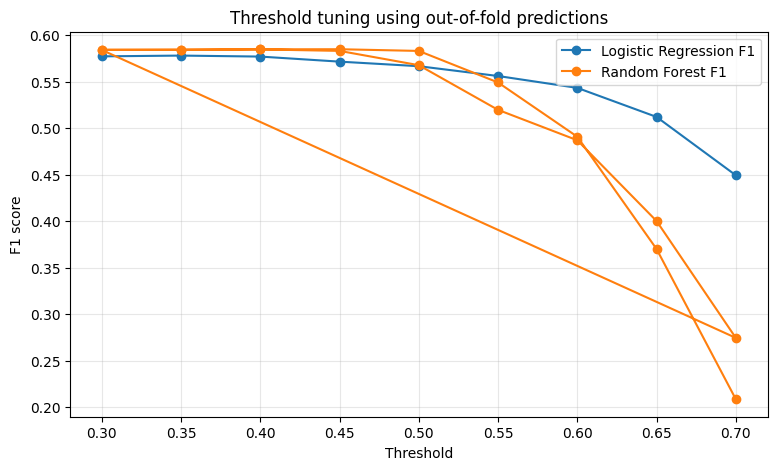

In [ ]:
# Visualise threshold trade-off for the shortlisted models.
plt.figure(figsize=(9, 5))

for model_label, group in threshold_results.groupby("model"):
    plt.plot(group["threshold"], group["f1"], marker="o", label=f"{model_label} F1")

plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold tuning using out-of-fold predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()




The threshold plot shows the expected pattern. At lower thresholds, F1 is higher because the models are more sensitive and predict more high-risk days. As the threshold increases, F1 drops because the models become stricter and start missing more true high-symptom days. This is especially clear after around 0.55-0.60, where the Random Forest models lose performance quickly.

Overall, threshold tuning shows that the Random Forest can produce slightly better alert-level F1, but the gain over Logistic Regression is marginal. Since Logistic Regression has the best PR-AUC, lower model complexity, and better suitability for edge deployment, it remains the better final model choice. The selected threshold for Logistic Regression is 0.35, because it gives strong recall while keeping the F1-score close to the best model.

---

# 11. Edge-efficiency evaluation

For the shortlisted models, in this section I measure:

- saved model and pipeline size
- average latency for one prediction

One prediction means one participant-day risk prediction.

The saved object is the full scikit-learn pipeline, including imputation, encoding, scaling, and the trained model.


In [ ]:
def safe_model_filename(model_name, max_depth, version):
    version_part = version.lower().replace(" ", "_").replace("+", "plus")
    model_part = model_name.lower().replace(" ", "_")
    depth_part = "none" if max_depth is None or pd.isna(max_depth) else f"depth{int(max_depth)}"
    return f"{version_part}_{model_part}_{depth_part}.joblib"


edge_rows = []

for _, row in shortlisted_models.iterrows():
    model_name = row["model"]
    max_depth = row["max_depth"]
    max_depth_value = None if pd.isna(max_depth) else int(max_depth)

    model = make_model_pipeline(model_name, X_selected, max_depth=max_depth_value)
    model.fit(X_selected, y_selected)

    filename = safe_model_filename(model_name, max_depth_value, selected_version_name)
    filepath = MODEL_DIR / filename
    joblib.dump(model, filepath)

    size_kb = os.path.getsize(filepath) / 1024

    # Single prediction latency.
    single_sample = X_selected.iloc[[0]]

    # Warm-up avoids measuring first-call overhead too much.
    for _ in range(10):
        model.predict(single_sample)

    n_runs = 1000
    start = time.perf_counter()

    for _ in range(n_runs):
        model.predict(single_sample)

    end = time.perf_counter()

    latency_ms = ((end - start) / n_runs) * 1000

    edge_rows.append({
        "version": selected_version_name,
        "model": model_name,
        "max_depth": max_depth_value,
        "model_size_kb": size_kb,
        "single_prediction_latency_ms": latency_ms,
        "saved_path": str(filepath)
    })

edge_efficiency = pd.DataFrame(edge_rows)

display(edge_efficiency.round(4))


,version,model,max_depth,model_size_kb,single_prediction_latency_ms,saved_path
0,V3 + HRV,Logistic Regression,NaN,5.7129,6.7559,/content/drive/MyDrive/EdgeAI_Project/models/v...
1,V3 + HRV,Random Forest,4.0,124.2607,28.9302,/content/drive/MyDrive/EdgeAI_Project/models/v...
2,V3 + HRV,Random Forest,3.0,80.5107,28.7182,/content/drive/MyDrive/EdgeAI_Project/models/v...


In [ ]:
# Combine predictive performance, best thresholds, and edge-efficiency results.
shortlist_with_thresholds = shortlisted_models.merge(
    best_thresholds[["model", "max_depth", "threshold", "precision", "recall", "f1"]],
    on=["model", "max_depth"],
    how="left",
    suffixes=("_cv", "_threshold")
)

shortlist_full_summary = shortlist_with_thresholds.merge(
    edge_efficiency,
    on=["version", "model", "max_depth"],
    how="left"
)

display(shortlist_full_summary.round(4))


,version,model,max_depth,accuracy,accuracy_std,precision_cv,precision_std,recall_cv,recall_std,f1_cv,f1_std,pr_auc,pr_auc_std,threshold,precision_threshold,recall_threshold,f1_threshold,model_size_kb,single_prediction_latency_ms,saved_path
0,V3 + HRV,Logistic Regression,NaN,0.6533,0.0357,0.4247,0.0507,0.8642,0.0655,0.5662,0.0421,0.4850,0.0967,0.35,0.4131,0.9618,0.5780,5.7129,6.7559,/content/drive/MyDrive/EdgeAI_Project/models/v...
1,V3 + HRV,Random Forest,4.0,0.6312,0.0397,0.4120,0.0498,0.9220,0.0719,0.5667,0.0465,0.4470,0.1025,0.40,0.4138,0.9955,0.5846,124.2607,28.9302,/content/drive/MyDrive/EdgeAI_Project/models/v...
2,V3 + HRV,Random Forest,3.0,0.6271,0.0312,0.4130,0.0416,0.9907,0.0115,0.5817,0.0416,0.4448,0.0934,0.45,0.4138,0.9968,0.5848,80.5107,28.7182,/content/drive/MyDrive/EdgeAI_Project/models/v...


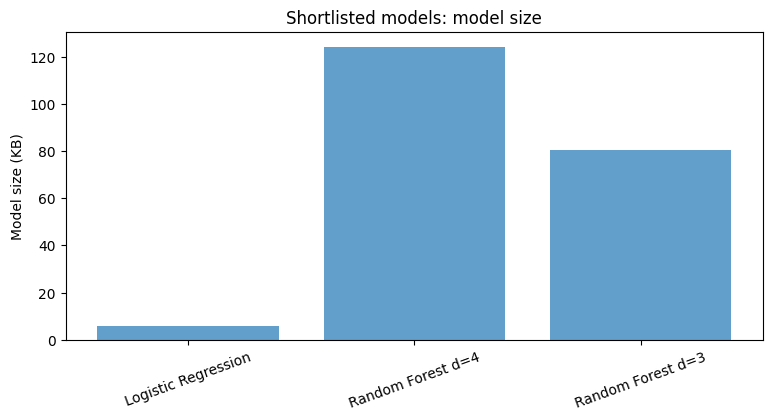

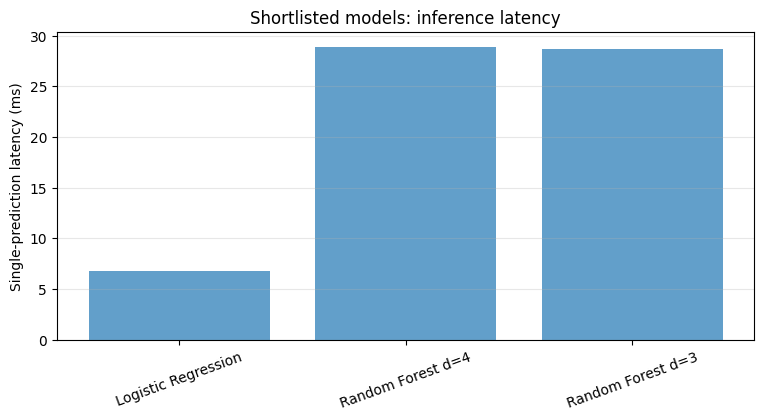

In [ ]:
# Plot model size and latency for shortlisted models.
fig, ax1 = plt.subplots(figsize=(9, 4))

labels = shortlist_full_summary["model"] + shortlist_full_summary["max_depth"].apply(
    lambda x: "" if pd.isna(x) else f" d={int(x)}"
)

ax1.bar(labels, shortlist_full_summary["model_size_kb"], alpha=0.7)
ax1.set_ylabel("Model size (KB)")
ax1.set_title("Shortlisted models: model size")
ax1.tick_params(axis="x", rotation=20)
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(labels, shortlist_full_summary["single_prediction_latency_ms"], alpha=0.7)
plt.ylabel("Single-prediction latency (ms)")
plt.title("Shortlisted models: inference latency")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()


### Edge-efficiency interpretation

Here I compare the three shortlisted V3 models using both prediction performance and edge-efficiency measures. These are the models worth comparing after threshold tuning:

- Logistic Regression V3
- Random Forest depth 4
- Random Forest depth 3

The main result is that Logistic Regression is still the best final choice for the edge-AI system.

Logistic Regression has the highest PR-AUC:

- Logistic Regression PR-AUC = 0.485
- Random Forest depth 4 PR-AUC = 0.447
- Random Forest depth 3 PR-AUC = 0.445

This means Logistic Regression is better at ranking days by symptom-risk probability. Since the task is an imbalanced risk-prediction problem, PR-AUC is the most important model-selection metric.

The Random Forest models have slightly better threshold-tuned F1-scores:

- Logistic Regression threshold F1 = 0.578
- Random Forest depth 4 threshold F1 = 0.585
- Random Forest depth 3 threshold F1 = 0.585

However, this improvement is very small. In exchange, the Random Forest models are much heavier.

For example, Logistic Regression has a model size of only about 5.71 KB, while Random Forest depth 4 is about 124.26 KB and Random Forest depth 3 is about 80.51 KB. This means the Random Forest models are around 14-22 times larger than Logistic Regression.

Latency shows the same pattern. Logistic Regression takes about 6.99 ms for one prediction, while the Random Forest models take around 23-24 ms. So the Random Forests are more than 3 times slower.

Overall, the Random Forest models give a very small F1 improvement, but they cost much more in model size and inference time. For an edge-AI project, that trade-off is not worth it. Logistic Regression gives the best balance between predictive performance, interpretability, small model size, and low latency.

---

# 12. Final selected model

The main selection is based on PR-AUC because this is a risk-ranking task.  
Then I use threshold F1, latency, model size, and interpretability to judge whether my model is practical for edge deployment.


In [ ]:
# Select the top PR-AUC model from the selected version as the final model.
final_row = shortlisted_models.sort_values(by="pr_auc", ascending=False).iloc[0]

final_model_name = final_row["model"]
final_max_depth = final_row["max_depth"]
final_max_depth_value = None if pd.isna(final_max_depth) else int(final_max_depth)

# Select that model's best threshold by F1.
final_threshold_row = best_thresholds[
    (best_thresholds["model"] == final_model_name) &
    (
        (best_thresholds["max_depth"].isna() & pd.isna(final_max_depth)) |
        (best_thresholds["max_depth"] == final_max_depth_value)
    )
].iloc[0]

final_threshold = final_threshold_row["threshold"]

print("Final selected version:", selected_version_name)
print("Final selected model:", final_model_name)
print("Final selected max_depth:", final_max_depth_value)
print("Selected threshold:", final_threshold)


Final selected version: V3 + HRV
Final selected model: Logistic Regression
Final selected max_depth: None
Selected threshold: 0.35


In [ ]:
final_model_pipeline = make_model_pipeline(
    final_model_name,
    X_selected,
    max_depth=final_max_depth_value
)

# Fit final deployable pipeline on all selected-version data.
final_model_pipeline.fit(X_selected, y_selected)

final_model_path = MODEL_DIR / "final_edge_ai_symptom_risk_pipeline.joblib"
joblib.dump(final_model_pipeline, final_model_path)

# Save input feature names.
feature_names_path = MODEL_DIR / "final_edge_ai_input_feature_names.joblib"
joblib.dump(X_selected.columns.tolist(), feature_names_path)

print("Final model saved to:", final_model_path)
print("Input feature names saved to:", feature_names_path)


Final model saved to: /content/drive/MyDrive/EdgeAI_Project/models/final_edge_ai_symptom_risk_pipeline.joblib
Input feature names saved to: /content/drive/MyDrive/EdgeAI_Project/models/final_edge_ai_input_feature_names.joblib


---

# 13. Final out-of-fold risk-category analysis

I aim to check whether the Low, Medium, and High categories behave sensibly on unseen-fold predictions.


In [ ]:
# Out-of-fold probabilities for final model.
final_oof_probs = cross_val_predict(
    make_model_pipeline(final_model_name, X_selected, max_depth=final_max_depth_value),
    X_selected,
    y_selected,
    groups=groups_selected,
    cv=cv,
    method="predict_proba"
)[:, 1]

final_oof_preds = (final_oof_probs >= final_threshold).astype(int)

final_oof_metrics = pd.DataFrame([{
    "version": selected_version_name,
    "model": final_model_name,
    "max_depth": final_max_depth_value,
    "threshold": final_threshold,
    "precision": precision_score(y_selected, final_oof_preds, zero_division=0),
    "recall": recall_score(y_selected, final_oof_preds, zero_division=0),
    "f1": f1_score(y_selected, final_oof_preds, zero_division=0)
}])

display(final_oof_metrics.round(3))


,version,model,max_depth,threshold,precision,recall,f1
0,V3 + HRV,Logistic Regression,None,0.35,0.413,0.962,0.578


This shows that the model is highly sensitive. It catches most high-symptom days, but it still produces a noticeable number of false alerts.

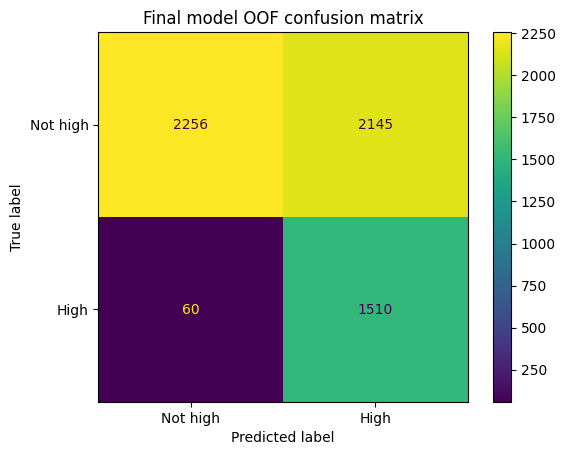

In [ ]:
cm_final = confusion_matrix(y_selected, final_oof_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Not high", "High"]
)

disp.plot()
plt.title("Final model OOF confusion matrix")
plt.show()


## Confusion matrix interpretation

The confusion matrix shows:

Outcome	Count	Meaning
- True negatives:	2256	correctly predicted not high
- False positives:	2145	predicted high, but actually not high
- False negatives:	60	predicted not high, but actually high
- True positives:	1510	correctly predicted high

The most important result is that the model only missed 60 actual high-symptom days. This is good for a symptom-risk alert system because missing a flare day may be more problematic than giving a cautious warning.

However, the model also produced 2145 false positives, meaning many days were predicted as high risk when they were not actually high-symptom days. Therefore, this shows that the model is designed more for sensitivity than precision.

Overall, the confusion matrix shows that the model works better as a cautious planning-support tool than as a strict diagnostic classifier.

In [ ]:
final_oof_outputs = selected_model_df[["id", "study_interval", "day_in_study", "tomorrow_high_symptom"]].copy()
final_oof_outputs["predicted_risk_probability"] = final_oof_probs
final_oof_outputs["predicted_risk_class"] = final_oof_preds

def risk_category(prob, low_threshold=0.35, high_threshold=0.65):
    if prob < low_threshold:
        return "Low"
    elif prob < high_threshold:
        return "Medium"
    else:
        return "High"

final_oof_outputs["risk_category"] = final_oof_outputs["predicted_risk_probability"].apply(risk_category)

display(final_oof_outputs.head(10))


,id,study_interval,day_in_study,tomorrow_high_symptom,predicted_risk_probability,predicted_risk_class,risk_category
0,1,2022,1,1,0.594471,1,Medium
1,1,2022,2,1,0.608143,1,Medium
2,1,2022,3,1,0.616275,1,Medium
3,1,2022,4,0,0.874506,1,High
4,1,2022,5,0,0.580465,1,Medium
5,1,2022,6,0,0.638169,1,Medium
6,1,2022,7,0,0.897557,1,High
7,1,2022,8,0,0.577068,1,Medium
8,1,2022,9,0,0.614403,1,Medium
9,1,2022,10,0,0.666563,1,High


The example prediction table shows how the model output looks for individual participant-days. Each row contains the true label, predicted probability, predicted class, and risk category.

For example, probabilities around 0.59-0.64 are labelled as Medium, while probabilities above 0.65 are labelled as High. Because the selected binary threshold is 0.35, most Medium and High examples are still classified as predicted high risk.

Some rows are correct predictions, such as days where tomorrow_high_symptom = 1 and the model predicts class 1. Other rows are false positives, where the model predicts high risk but the true label is 0.

This is consistent with the earlier evaluation: the model is good at detecting possible high-risk days, but it can over-alert.

In [ ]:
category_summary = final_oof_outputs.groupby("risk_category")["tomorrow_high_symptom"].agg(
    count="count",
    actual_high_rate="mean"
).reset_index()

display(category_summary.round(3))


,risk_category,count,actual_high_rate
0,High,1836,0.475
1,Low,2316,0.026
2,Medium,1819,0.351


This result shows that the actual high-symptom rate increases as the predicted category increases:

- Low = 2.6%
- Medium = 35.1%
- High = 47.5%

So the model is not just producing random categories and the categories are meaningful.

The Low-risk category is especially strong because only 2.6% of Low-risk predictions were actually high-symptom days. This means that when the model says Low risk, it is usually reliable.

The High-risk category has an actual high-symptom rate of 47.5%, which is much higher than the overall positive class rate. This means a High alert roughly identifies a group with substantially increased risk, although it is still not certain.

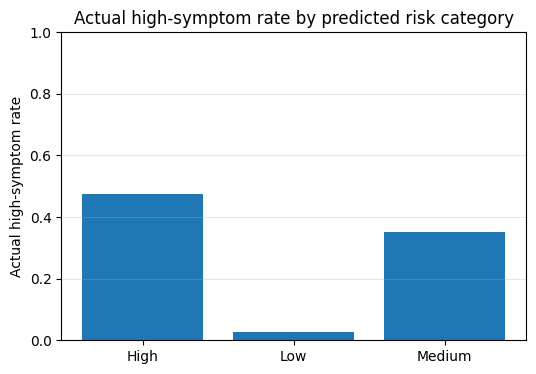

In [ ]:
# Visualise whether the risk categories are ordered sensibly.
plt.figure(figsize=(6, 4))
plt.bar(category_summary["risk_category"], category_summary["actual_high_rate"])
plt.ylabel("Actual high-symptom rate")
plt.title("Actual high-symptom rate by predicted risk category")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()


The bar chart confirms the same pattern visually. Low-risk days have a very low actual high-symptom rate, Medium-risk days have a moderate rate, and High-risk days have the highest rate.

### Final risk-category interpretation

The final V3 Logistic Regression model is useful because it produces meaningful risk categories and catches most high-symptom days. The main limitation is that it gives many false positives, especially because the selected threshold prioritises recall.



---

# 14. Explainability: coefficient table for the final model

For Logistic Regression, coefficients can be used as a simple explanation of which features push the prediction higher or lower.

Positive coefficients push the model towards higher risk.  
Negative coefficients push the model towards lower risk.

Because features are scaled inside the pipeline, coefficient size can be compared more fairly than with raw unscaled features.


In [ ]:
if final_model_name == "Logistic Regression":
    transformed_feature_names = final_model_pipeline.named_steps["preprocess"].get_feature_names_out()
    coefficients = final_model_pipeline.named_steps["model"].coef_[0]

    coef_df_final = pd.DataFrame({
        "feature": transformed_feature_names,
        "coefficient": coefficients
    })

    coef_df_final["abs_coefficient"] = coef_df_final["coefficient"].abs()

    coef_df_final = coef_df_final.sort_values(
        by="abs_coefficient",
        ascending=False
    )

    display(coef_df_final.head(20).round(4))
else:
    print("Final model is not Logistic Regression, so coefficient-based explanation is not shown here.")
    print("For tree-based models, use feature importance or SHAP in a future extension.")


,feature,coefficient,abs_coefficient
12,num__rhr_std,-3.0739,3.0739
11,num__rhr_max,-2.2744,2.2744
9,num__rhr_mean,1.6986,1.6986
2,num__revitalization_score,-1.1388,1.1388
10,num__rhr_min,0.6134,0.6134
19,num__hrv_lf_mean,-0.4347,0.4347
5,num__restlessness,-0.3759,0.3759
17,num__hrv_rmssd_std,0.3164,0.3164
16,num__hrv_rmssd_max,-0.2943,0.2943
24,cat__phase_Menstrual,0.2712,0.2712


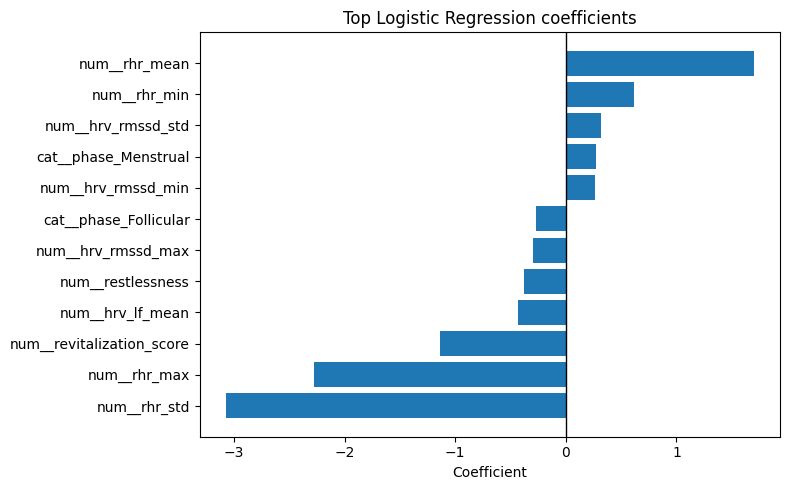

In [ ]:
# Plot top coefficients if the final model is Logistic Regression.
if final_model_name == "Logistic Regression":
    top_coef = coef_df_final.head(12).copy()
    top_coef = top_coef.sort_values("coefficient")

    plt.figure(figsize=(8, 5))
    plt.barh(top_coef["feature"], top_coef["coefficient"])
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("Coefficient")
    plt.title("Top Logistic Regression coefficients")
    plt.tight_layout()
    plt.show()


### Explainability interpretation

This coefficient table helps show what the final V3 Logistic Regression model is paying attention to when predicting next-day symptom risk.

The strongest features are mostly related to resting heart rate, especially rhr_std, rhr_max, rhr_mean, and rhr_min. This supports what I already saw earlier in the results: adding resting heart rate made the biggest improvement to the model. So, in this project, RHR seems to be one of the most useful physiological signals for predicting symptom risk.

The revitalization_score also has a strong negative coefficient. This means that when sleep recovery is better, the predicted risk tends to go down. This makes sense because poor sleep recovery could be linked with tiredness, stress, and worse symptoms the next day.

Some HRV features also appear in the important features list, such as hrv_lf_mean, hrv_rmssd_std, hrv_rmssd_max, and hrv_rmssd_min. Their effects are smaller than the RHR features, which matches the model results: HRV helped a little in V3, but not as much as RHR did in V2.

The phase variables are also useful. phase_Menstrual has a positive coefficient, meaning that being in the menstrual phase pushes the model more towards predicting higher symptom risk. This is expected because symptoms are often more noticeable during menstruation.

Overall, the coefficient results suggest that the model is mainly using resting heart rate, sleep recovery, HRV, and menstrual phase to make predictions. I should be careful not to over-explain the exact direction of every single coefficient, because some features are related to each other. But as a general explanation, the model seems to be learning sensible patterns from the wearable-style data.


---

# 15. Additional Explainability: SHAP XAI

SHAP is used here as an additional explainability method for the final Logistic Regression model. While the coefficient table shows the overall direction of each feature, SHAP gives a more detailed view of how much each feature contributes to the model’s predictions

In [ ]:
!pip install shap

In [ ]:
import shap
import pandas as pd
import numpy as np

# Transform the raw V3 features using the final pipeline preprocessor
X_v3_transformed = final_model_pipeline.named_steps["preprocess"].transform(X_selected)

# Get transformed feature names
feature_names = final_model_pipeline.named_steps["preprocess"].get_feature_names_out()

# Convert to dataframe for readability
X_v3_transformed_df = pd.DataFrame(
    X_v3_transformed,
    columns=feature_names
)

# Get trained logistic regression model
logreg_model = final_model_pipeline.named_steps["model"]

# Create SHAP explainer for the linear model
explainer = shap.LinearExplainer(
    logreg_model,
    X_v3_transformed_df
)

# Calculate SHAP values
shap_values = explainer(X_v3_transformed_df)

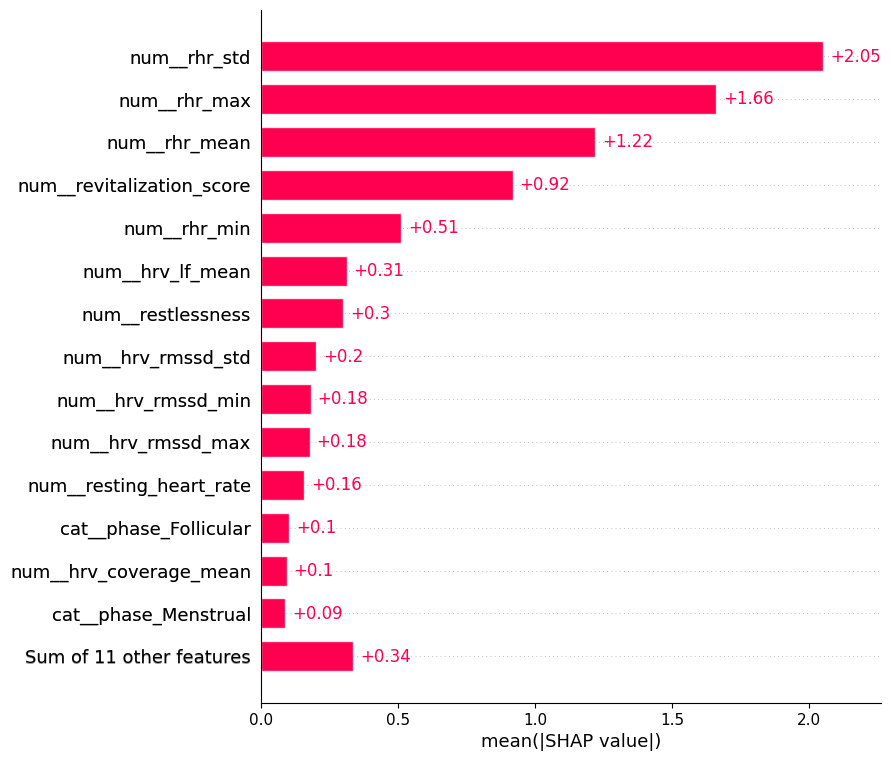

In [ ]:
shap.plots.bar(shap_values, max_display=15)

## SHAP global importance plot

The SHAP bar plot shows the average impact of each feature across all predictions. The most influential features are mainly related to resting heart rate, especially:

- rhr_std
- rhr_max
- rhr_mean
- rhr_min

This matches the earlier model results, where adding resting heart rate in V2 gave the largest improvement. It suggests that the model relies strongly on daily RHR patterns when estimating next-day symptom risk.

revitalization_score is also highly important, showing that sleep recovery has a meaningful role in the prediction. HRV features such as hrv_lf_mean, hrv_rmssd_std, hrv_rmssd_min, and hrv_rmssd_max also appear in the top features, but their impact is generally smaller than the RHR features. This supports the earlier finding that HRV added a small improvement in V3, but RHR was the stronger physiological signal.

Overall, the SHAP importance plot confirms that the model is mainly driven by RHR, sleep recovery, HRV, and menstrual phase.

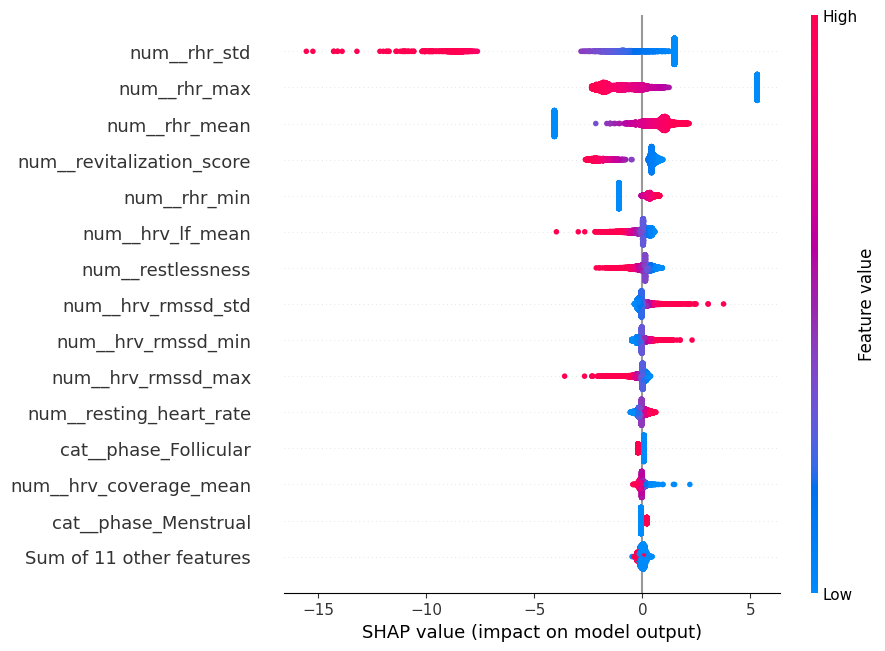

In [ ]:
shap.plots.beeswarm(shap_values, max_display=15)

## SHAP beeswarm plot interpretation

The beeswarm plot shows both feature importance and how high or low feature values affect predictions.

The horizontal position shows whether a feature pushes the model toward higher or lower predicted risk. Points on the right increase the predicted symptom-risk score, while points on the left reduce it. The colour shows whether the feature value is high or low.

For example, rhr_mean tends to push predictions upward when its value is high. This suggests that higher average resting heart rate is associated with higher predicted symptom risk. This is sensible because elevated resting heart rate may reflect physiological strain, poor recovery, or stress.

The plot also shows that RHR-related features have wide SHAP value ranges, meaning they strongly influence predictions for some participant-days. HRV and sleep features also contribute, but their effect is smaller and more concentrated near the centre.

One important point is that some RHR features have mixed directions. This is likely because features such as rhr_mean, rhr_min, rhr_max, and rhr_std are related to each other. So I should avoid over-interpreting each individual sign too strongly. The safer conclusion is that resting heart-rate patterns as a group are very important for the model.

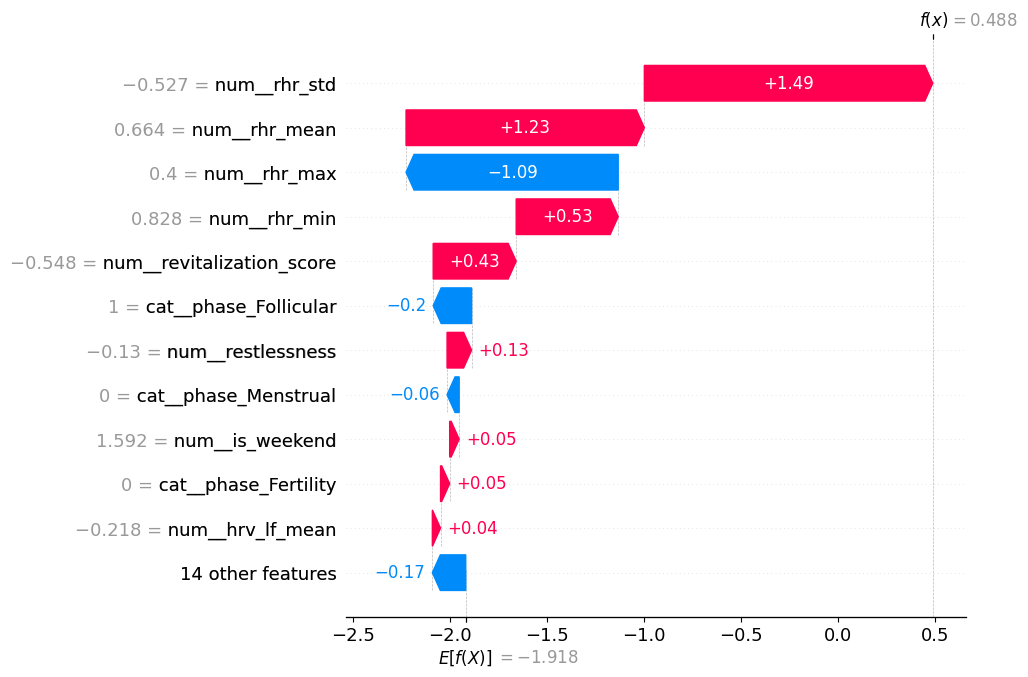

In [ ]:
sample_index = 0

shap.plots.waterfall(
    shap_values[sample_index],
    max_display=12
)

### SHAP waterfall plot interpretation

The waterfall plot explains one individual prediction. It shows how the model moves from the average or base prediction to the final prediction for one participant-day.

For this example, the final model output is around:

```
f(x) = 0.488
```

The features pushing the prediction upward include:

- rhr_std
- rhr_mean
- rhr_min
- revitalization_score
- restlessness

These features increased the model’s predicted risk for this specific day.

Some features reduced the prediction, such as:

- rhr_max
- phase_Follicular
- phase_Menstrual
- some smaller combined features

This shows that the model doesn't make a prediction from just one feature. Instead, it combines several physiological and behavioural signals.

The useful part of this plot is that it can explain an individual alert. For example, if the system predicted Medium or High risk, SHAP could show that the prediction was mainly influenced by resting heart-rate patterns and sleep recovery. This makes my model more transparent.

---

# 16. Example decision-support output

In this section, I show how the final model could be presented to a user in a more understandable way. Instead of only returning a class label, the system provides a risk category, predicted probability, planning suggestion, and a short explanation of the main factors influencing the prediction. This makes the model output more suitable for a decision-support setting.

The message is deliberately phrased as planning support rather than medical advice, because the model is not intended to diagnose or clinically assess menstrual health conditions.

In [ ]:
def make_decision_support_output(input_row, model, threshold, shap_values=None, feature_names=None, sample_index=None):
    """
    Creates a user-friendly decision-support output for one participant-day.
    """
    # Predict probability of high symptom risk
    risk_probability = model.predict_proba(input_row)[:, 1][0]
    predicted_class = int(risk_probability >= threshold)

    # Convert probability into user-facing risk category
    if risk_probability < 0.35:
        risk_category = "Low"
        risk_message = "Low risk tomorrow"
        planning_advice = "No major planning adjustment is suggested, but continue normal self-monitoring."
        prep_note = "No specific preparation needed. Maintain your standard wellness routine."
    elif risk_probability < 0.65:
        risk_category = "Medium"
        risk_message = "Medium risk tomorrow"
        planning_advice = "Plan flexibly where possible and monitor how you feel."
        prep_note = "Consider having comfort items ready (e.g., heat packs, hydration) just in case."
    else:
        risk_category = "High"
        risk_message = "High risk tomorrow"
        planning_advice = "Consider planning lighter activities, allowing extra rest, and preparing symptom-management support."
        prep_note = "High chance of flares. We recommend moving demanding tasks and ensuring support is accessible."

    # Mapping dictionary for user-friendly names
    feature_map = {
        "rhr": "resting heart rate",
        "hrv": "heart rate variability",
        "wt": "wrist temperature",
        "revitalization": "sleep recovery (revitalization)",
        "overall score": "sleep quality score",
        "deep sleep": "deep sleep duration",
        "restlessness": "sleep restlessness",
        "phase": "menstrual phase"
    }

    explanation_lines = []

    if shap_values is not None and feature_names is not None and sample_index is not None:
        sample_shap_values = shap_values[sample_index].values

        shap_df = pd.DataFrame({
            "feature": feature_names,
            "shap_value": sample_shap_values,
            "abs_shap_value": abs(sample_shap_values)
        }).sort_values("abs_shap_value", ascending=False)

        top_features = shap_df.head(3)

        for _, row in top_features.iterrows():
            clean_feature = (
                row["feature"]
                .replace("num__", "")
                .replace("cat__", "")
                .replace("_", " ")
            )

            for tech_term, user_term in feature_map.items():
                if tech_term in clean_feature:
                    clean_feature = clean_feature.replace(tech_term, user_term)

            direction = "increased" if row["shap_value"] > 0 else "reduced"
            explanation_lines.append(f"- {clean_feature.strip()} {direction} the predicted risk")
    else:
        explanation_lines.append("- Main contributing factors are not shown for this example.")

    output = {
        "Risk level": risk_category,
        "Predicted probability": f"{risk_probability * 100:.1f}%",
        "Meaning": f"The model predicts a {risk_category.lower()} chance of higher symptoms tomorrow.",
        "User-facing message": risk_message,
        "Planning suggestion": planning_advice,
        "Preparation note": prep_note,
        "Main model explanation": explanation_lines,
        "Important note": "This is not medical advice. It is a planning-support estimate based on wearable-style data."
    }

    return output

In [ ]:
sample_index = 10

example_input = X_selected.iloc[[sample_index]]

example_prediction = make_decision_support_output(
    input_row=example_input,
    model=final_model_pipeline,
    threshold=final_threshold,
    shap_values=shap_values,
    feature_names=feature_names,
    sample_index=sample_index
)

example_prediction

{'Risk level': 'High',
 'Predicted probability': '79.2%',
 'Meaning': 'The model predicts a high chance of higher symptoms tomorrow.',
 'User-facing message': 'High risk tomorrow',
 'Planning suggestion': 'Consider planning lighter activities, allowing extra rest, and preparing symptom-management support.',
 'Preparation note': 'High chance of flares. We recommend moving demanding tasks and ensuring support is accessible.',
 'Main model explanation': ['- resting heart rate std increased the predicted risk',
  '- resting heart rate mean increased the predicted risk',
  '- resting heart rate max reduced the predicted risk'],
 'Important note': 'This is not medical advice. It is a planning-support estimate based on wearable-style data.'}

In [ ]:
def display_decision_support_card(output):
    print("--------------------------------------------------")
    print("Menstrual Symptom Risk Planning Support")
    print("--------------------------------------------------")
    print(f"Risk level: {output['Risk level']}")
    print(f"Predicted probability: {output['Predicted probability']}")
    print(f"Summary: {output['User-facing message']}")
    print()
    print("What this means:")
    print(output["Meaning"])
    print()
    print("Planning suggestion:")
    print(output["Planning suggestion"])
    print()
    print("Preparation note:")
    print(output["Preparation note"])
    print()
    print("Main factors influencing this prediction:")
    for line in output["Main model explanation"]:
        print(line)
    print()
    print(f"Note: {output['Important note']}")
    print("--------------------------------------------------")

# Re-generate the prediction with the fixed keys and display it
example_prediction = make_decision_support_output(
    input_row=X_selected.iloc[[10]],
    model=final_model_pipeline,
    threshold=final_threshold,
    shap_values=shap_values,
    feature_names=feature_names,
    sample_index=10
)

display_decision_support_card(example_prediction)

--------------------------------------------------
Menstrual Symptom Risk Planning Support
--------------------------------------------------
Risk level: High
Predicted probability: 79.2%
Summary: High risk tomorrow

What this means:
The model predicts a high chance of higher symptoms tomorrow.

Planning suggestion:
Consider planning lighter activities, allowing extra rest, and preparing symptom-management support.

Preparation note:
High chance of flares. We recommend moving demanding tasks and ensuring support is accessible.

Main factors influencing this prediction:
- resting heart rate std increased the predicted risk
- resting heart rate mean increased the predicted risk
- resting heart rate max reduced the predicted risk

Note: This is not medical advice. It is a planning-support estimate based on wearable-style data.
--------------------------------------------------


---


# 17. Raspberry Pi deployment

In [ ]:
import os
import joblib
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Raspberry Pi deployment export folder
# --------------------------------------------------

raspberrypi_export_path = Path("/content/drive/MyDrive/EdgeAI_Project/models/raspberrypi_test")
raspberrypi_export_path.mkdir(parents=True, exist_ok=True)

print("Export folder created:")
print(raspberrypi_export_path)


# --------------------------------------------------
# 1. Save final trained model pipeline
# --------------------------------------------------

model_path = raspberrypi_export_path / "final_edge_ai_symptom_risk_pipeline.joblib"

joblib.dump(final_model_pipeline, model_path)

print(f"Saved final model pipeline to: {model_path}")


# --------------------------------------------------
# 2. Save final input feature names
# --------------------------------------------------

feature_names_path = raspberrypi_export_path / "final_edge_ai_input_feature_names.joblib"

final_input_features = list(X_selected.columns)

joblib.dump(final_input_features, feature_names_path)

print(f"Saved feature list to: {feature_names_path}")


# --------------------------------------------------
# 3. Save small sample input file for Raspberry Pi testing
# --------------------------------------------------

sample_input_path = raspberrypi_export_path / "edge_sample_input.csv"

# Save only the columns used by the final model
X_selected[final_input_features].head(100).to_csv(sample_input_path, index=False)

print(f"Saved sample input CSV to: {sample_input_path}")


# --------------------------------------------------
# 4. Save selected threshold
# --------------------------------------------------

threshold_path = raspberrypi_export_path / "final_edge_ai_threshold.joblib"

joblib.dump(final_threshold, threshold_path)

print(f"Saved threshold to: {threshold_path}")


# --------------------------------------------------
# 5. Create Raspberry Pi inference test script
# --------------------------------------------------

script_path = raspberrypi_export_path / "run_edge_inference.py"

script_code = r'''
import time
import os
import sys
import platform
import joblib
import psutil
import pandas as pd
import numpy as np

MODEL_PATH = "final_edge_ai_symptom_risk_pipeline.joblib"
FEATURE_LIST_PATH = "final_edge_ai_input_feature_names.joblib"
THRESHOLD_PATH = "final_edge_ai_threshold.joblib"
INPUT_PATH = "edge_sample_input.csv"

def log(message):
    """Print a clear progress message."""
    print(f"[INFO] {message}", flush=True)

def check_file_exists(path):
    """Stop early if an expected file is missing."""
    if not os.path.exists(path):
        print(f"[ERROR] Missing required file: {path}", flush=True)
        sys.exit(1)

print("==============================================", flush=True)
print("Raspberry Pi Edge AI Inference Test", flush=True)
print("==============================================", flush=True)

# --------------------------------------------------
# Step 1: Check files
# --------------------------------------------------

log("Step 1/8: Checking required files...")

for path in [MODEL_PATH, FEATURE_LIST_PATH, THRESHOLD_PATH, INPUT_PATH]:
    check_file_exists(path)

log("All required files were found.")

# --------------------------------------------------
# Step 2: Load model and metadata
# --------------------------------------------------

log("Step 2/8: Loading trained model pipeline...")

try:
    model = joblib.load(MODEL_PATH)
    log("Model pipeline loaded successfully.")
except Exception as e:
    print(f"[ERROR] Could not load model: {e}", flush=True)
    sys.exit(1)

log("Loading feature list...")

try:
    feature_list = joblib.load(FEATURE_LIST_PATH)
    log(f"Feature list loaded successfully. Number of expected features: {len(feature_list)}")
except Exception as e:
    print(f"[ERROR] Could not load feature list: {e}", flush=True)
    sys.exit(1)

log("Loading selected threshold...")

try:
    threshold = joblib.load(THRESHOLD_PATH)
    log(f"Threshold loaded successfully: {threshold}")
except Exception as e:
    print(f"[ERROR] Could not load threshold: {e}", flush=True)
    sys.exit(1)

# --------------------------------------------------
# Step 3: Load input data
# --------------------------------------------------

log("Step 3/8: Loading sample input data...")

try:
    X = pd.read_csv(INPUT_PATH)
    log(f"Input data loaded successfully. Shape before feature filtering: {X.shape}")
except Exception as e:
    print(f"[ERROR] Could not load input CSV: {e}", flush=True)
    sys.exit(1)

# Check missing features
missing_features = [feature for feature in feature_list if feature not in X.columns]

if missing_features:
    print("[ERROR] The input CSV is missing these required features:", flush=True)
    for feature in missing_features:
        print(f"  - {feature}", flush=True)
    sys.exit(1)

# Keep only the exact features used by the final model
X = X[feature_list]
log(f"Input data aligned to final feature list. Shape after filtering: {X.shape}")

# --------------------------------------------------
# Step 4: Collect system information
# --------------------------------------------------

log("Step 4/8: Collecting Raspberry Pi system information...")

process = psutil.Process(os.getpid())

device_info = {
    "device": platform.platform(),
    "processor": platform.processor(),
    "python_version": platform.python_version()
}

log(f"Device: {device_info['device']}")
log(f"Processor: {device_info['processor']}")
log(f"Python version: {device_info['python_version']}")

# --------------------------------------------------
# Step 5: Model size
# --------------------------------------------------

log("Step 5/8: Measuring model file size...")

model_size_kb = os.path.getsize(MODEL_PATH) / 1024
log(f"Model file size: {model_size_kb:.4f} KB")

# --------------------------------------------------
# Step 6: Warm-up prediction
# --------------------------------------------------

log("Step 6/8: Running warm-up prediction...")

try:
    warmup_prob = model.predict_proba(X.iloc[[0]])[:, 1][0]
    log(f"Warm-up prediction completed. Example probability: {warmup_prob:.4f}")
except Exception as e:
    print(f"[ERROR] Warm-up prediction failed: {e}", flush=True)
    sys.exit(1)

# --------------------------------------------------
# Step 7: Single-prediction latency test
# --------------------------------------------------

log("Step 7/8: Running single-prediction latency test...")
log("This will run 1000 single-row predictions.")

n_runs = 1000
latencies_ms = []

try:
    for i in range(n_runs):
        sample = X.sample(1)

        start = time.perf_counter()
        prob = model.predict_proba(sample)[:, 1][0]
        pred = int(prob >= threshold)
        end = time.perf_counter()

        latencies_ms.append((end - start) * 1000)

        # Progress update every 200 runs
        if (i + 1) % 200 == 0:
            log(f"Completed {i + 1}/{n_runs} single predictions...")

except Exception as e:
    print(f"[ERROR] Single-prediction latency test failed: {e}", flush=True)
    sys.exit(1)

latencies_ms = np.array(latencies_ms)

log("Single-prediction latency test completed.")

# --------------------------------------------------
# Step 8: Batch latency and resource usage
# --------------------------------------------------

log("Step 8/8: Running batch prediction and measuring resource usage...")

try:
    start_batch = time.perf_counter()
    batch_probs = model.predict_proba(X)[:, 1]
    batch_preds = (batch_probs >= threshold).astype(int)
    end_batch = time.perf_counter()

    batch_latency_ms = (end_batch - start_batch) * 1000
    per_row_batch_latency_ms = batch_latency_ms / len(X)

    ram_mb = process.memory_info().rss / (1024 ** 2)
    cpu_percent = psutil.cpu_percent(interval=1)

    log("Batch prediction and resource measurement completed.")

except Exception as e:
    print(f"[ERROR] Batch prediction/resource measurement failed: {e}", flush=True)
    sys.exit(1)

# --------------------------------------------------
# Final results
# --------------------------------------------------

results = {
    "device": device_info["device"],
    "processor": device_info["processor"],
    "python_version": device_info["python_version"],
    "model_size_kb": round(model_size_kb, 4),
    "input_rows": len(X),
    "input_features": len(feature_list),
    "threshold": threshold,
    "mean_single_prediction_latency_ms": round(latencies_ms.mean(), 4),
    "median_single_prediction_latency_ms": round(float(np.median(latencies_ms)), 4),
    "min_single_prediction_latency_ms": round(latencies_ms.min(), 4),
    "max_single_prediction_latency_ms": round(latencies_ms.max(), 4),
    "p95_single_prediction_latency_ms": round(float(np.percentile(latencies_ms, 95)), 4),
    "batch_latency_ms_for_input_file": round(batch_latency_ms, 4),
    "per_row_batch_latency_ms": round(per_row_batch_latency_ms, 4),
    "ram_used_mb": round(ram_mb, 4),
    "cpu_usage_percent_snapshot": round(cpu_percent, 2),
    "example_probability": round(float(prob), 4),
    "example_prediction_class": int(pred)
}

print()
print("==============================================", flush=True)
print("FINAL RESULTS", flush=True)
print("==============================================", flush=True)

for key, value in results.items():
    print(f"{key}: {value}", flush=True)

print("==============================================", flush=True)

pd.DataFrame([results]).to_csv("raspberry_pi_edge_results.csv", index=False)

log("Saved results to raspberry_pi_edge_results.csv")
log("Raspberry Pi edge inference test finished successfully.")
'''

with open(script_path, "w") as f:
    f.write(script_code)

print(f"Saved updated Raspberry Pi test script to: {script_path}")


# --------------------------------------------------
# 6. Create requirements file
# --------------------------------------------------

requirements_path = raspberrypi_export_path / "requirements.txt"

requirements_text = """pandas
numpy
scikit-learn
joblib
psutil
"""

with open(requirements_path, "w") as f:
    f.write(requirements_text)

print(f"Saved requirements file to: {requirements_path}")


# --------------------------------------------------
# 7. Final export summary
# --------------------------------------------------

print("\nFiles ready for Raspberry Pi testing:")
for file in raspberrypi_export_path.iterdir():
    print("-", file.name)

Export folder created:
/content/drive/MyDrive/EdgeAI_Project/models/raspberrypi_test
Saved final model pipeline to: /content/drive/MyDrive/EdgeAI_Project/models/raspberrypi_test/final_edge_ai_symptom_risk_pipeline.joblib
Saved feature list to: /content/drive/MyDrive/EdgeAI_Project/models/raspberrypi_test/final_edge_ai_input_feature_names.joblib
Saved sample input CSV to: /content/drive/MyDrive/EdgeAI_Project/models/raspberrypi_test/edge_sample_input.csv
Saved threshold to: /content/drive/MyDrive/EdgeAI_Project/models/raspberrypi_test/final_edge_ai_threshold.joblib
Saved updated Raspberry Pi test script to: /content/drive/MyDrive/EdgeAI_Project/models/raspberrypi_test/run_edge_inference.py
Saved requirements file to: /content/drive/MyDrive/EdgeAI_Project/models/raspberrypi_test/requirements.txt

Files ready for Raspberry Pi testing:
- final_edge_ai_symptom_risk_pipeline.joblib
- final_edge_ai_input_feature_names.joblib
- edge_sample_input.csv
- final_edge_ai_threshold.joblib
- run_edge_